
# Explainable & Imbalance-Aware Machine Learning Framework for Collegiate Athlete Injury Risk Prediction
### An Extended, Feature-Engineered Replication and Improvement of Raju et al. (2026), *BMC Sports Science, Medicine and Rehabilitation*

**Base paper:** Raju S., Singamaneni K.K., Hooi L.B., Rani K.U., Chandrika B. (2026). *Machine learning framework for predicting athletic injuries and optimising performance.* BMC Sports Sci Med Rehabil 18, 107. https://doi.org/10.1186/s13102-025-01502-x

---

## What the base paper did
- Used the public Kaggle **"Athlete Injury and Performance Dataset"** (n = 200, 17 variables).
- Preprocessing: min-max scaling, one-hot encoding, z-score outlier inspection, **only two derived ratios** (training-to-recovery ratio, exposure-to-rest ratio).
- Modeling: **PyCaret AutoML** black-box selection over Random Forest, XGBoost and a single ANN.
- Validation: 5-fold stratified CV; metrics = Accuracy, Precision, Recall, F1, ROC-AUC.
- Explainability: global SHAP summary only (no local explanations, no dependence plots).
- **No explicit class-imbalance handling** was reported (the injury class is ~20% of the sample) and PCA was tried but "not used" because only 17 raw variables existed.
- Best result: Random Forest, Accuracy ≈ 0.98, ROC-AUC ≈ 0.97, F1 ≈ 0.81.

## The novelty of this work
| Dimension | Base paper | This notebook |
|---|---|---|
| Feature engineering | 2 ratio features | **12+ engineered features**: workload/recovery ratios, ACWR-proxy, composite fatigue-readiness index, BMI, position risk encoding, interaction terms, unsupervised cluster-profile feature |
| Feature justification | None | Mutual-information / ANOVA-F statistical validation of every engineered feature vs. raw features |
| Class imbalance | Not addressed | **SMOTE** oversampling (train-only) + class-weighted baselines compared explicitly |
| Model diversity | RF, XGBoost, ANN (via AutoML) | Logistic Regression, Random Forest, XGBoost, **LightGBM**, SVM, MLP, and a **Stacking ensemble meta-learner** — each with explicit, transparent hyperparameter search (no AutoML black box) |
| Evaluation | Accuracy/F1/ROC-AUC only | Adds **PR-AUC** (important under imbalance), calibration curve, **McNemar's statistical significance test** between top models |
| Explainability | Global SHAP bar only | Global SHAP summary + **dependence plots** + **local waterfall explanation per athlete** + permutation importance cross-check |
| Decision support | None | **Threshold optimisation** (Youden's J / F1-max) for a clinically usable operating point |
| Final deliverable | Reported metrics only | A packaged, reusable **`InjuryRiskPredictor`** class (preprocessing + model + explanation bundled) that scores a *new* athlete and returns a Low/Moderate/High risk category with the top SHAP reasons — i.e., a deployable product, not just a notebook of metrics |

## 0. Environment Setup & Imports

In [1]:

# ============================================================
# STEP 0: PACKAGES & ENVIRONMENT SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve, auc,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['figure.dpi'] = 110

print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Data Loading
Loads the real dataset if present, otherwise builds a schema-matched synthetic fallback
(200 athletes, 17 columns, ~20% injury base rate, with the same directionality of
relationships reported by the base paper: higher training intensity/hours, lower recovery,
higher fatigue and ACL-risk, and lower load-balance are associated with higher injury
probability).

In [2]:

# ============================================================
# STEP 1: LOAD DATA (real CSV first, schema-matched synthetic fallback otherwise)
# ============================================================
import os

DATA_PATH = "collegiate_athlete_injury_dataset.csv"

def generate_synthetic_fallback(n=200, seed=RANDOM_STATE):
    '''Schema-matched synthetic generator used ONLY if the real CSV is not found.
    Replace with your real collegiate_athlete_injury_dataset.csv for actual results.'''
    rng = np.random.default_rng(seed)

    gender = rng.choice(['Male', 'Female'], size=n, p=[0.55, 0.45])
    position = rng.choice(['Forward', 'Midfielder', 'Defender', 'Goalkeeper'],
                           size=n, p=[0.3, 0.3, 0.3, 0.1])

    age = rng.integers(18, 25, size=n)
    height = np.where(gender == 'Male',
                       rng.normal(178, 7, n), rng.normal(166, 6, n)).round().astype(int)
    weight = np.where(gender == 'Male',
                       rng.normal(75, 9, n), rng.normal(60, 8, n)).round().astype(int)

    training_intensity = rng.integers(1, 11, size=n)
    training_hours = rng.integers(4, 25, size=n)
    recovery_days = rng.integers(1, 5, size=n)
    match_count = rng.integers(0, 5, size=n)
    rest_between = rng.integers(1, 8, size=n)

    # latent injury propensity driven by workload/recovery imbalance (mirrors base-paper findings)
    z = (
        0.9 * (training_intensity - training_intensity.mean()) / training_intensity.std()
        + 0.8 * (training_hours - training_hours.mean()) / training_hours.std()
        - 0.9 * (recovery_days - recovery_days.mean()) / recovery_days.std()
        + 0.6 * (match_count - match_count.mean()) / match_count.std()
        - 0.5 * (rest_between - rest_between.mean()) / rest_between.std()
        + rng.normal(0, 0.7, n)
    )

    fatigue_score = np.clip((50 + 12 * z + rng.normal(0, 6, n)), 0, 100).round().astype(int)
    acl_risk_score = np.clip((45 + 13 * z + rng.normal(0, 7, n)), 0, 100).round().astype(int)
    load_balance_score = np.clip((60 - 10 * z + rng.normal(0, 8, n)), 0, 100).round().astype(int)
    performance_score = np.clip((70 - 4 * z + rng.normal(0, 9, n)), 0, 100).round().astype(int)
    team_contribution_score = np.clip((65 - 3 * z + rng.normal(0, 9, n)), 0, 100).round().astype(int)

    injury_prob = 1 / (1 + np.exp(-(1.15 * z - 0.55)))
    injury_indicator = (rng.random(n) < injury_prob).astype(int)

    # enforce an approximate ~20% base rate as reported in the base paper
    target_rate = 0.20
    current_rate = injury_indicator.mean()
    if current_rate > 0:
        adjust = target_rate / current_rate
        injury_indicator = (rng.random(n) < np.clip(injury_prob * adjust, 0, 1)).astype(int)

    df_syn = pd.DataFrame({
        'Athlete_ID': [f'ATH{str(i).zfill(3)}' for i in range(1, n + 1)],
        'Age': age,
        'Gender': gender,
        'Height_cm': height,
        'Weight_kg': weight,
        'Position': position,
        'Training_Intensity': training_intensity,
        'Training_Hours_Per_Week': training_hours,
        'Recovery_Days_Per_Week': recovery_days,
        'Match_Count_Per_Week': match_count,
        'Rest_Between_Events_Days': rest_between,
        'Fatigue_Score': fatigue_score,
        'Performance_Score': performance_score,
        'Team_Contribution_Score': team_contribution_score,
        'Load_Balance_Score': load_balance_score,
        'ACL_Risk_Score': acl_risk_score,
        'Injury_Indicator': injury_indicator
    })
    return df_syn


if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded REAL dataset from '{DATA_PATH}'.")
else:
    df = generate_synthetic_fallback()
    print(f"'{DATA_PATH}' not found — using a SCHEMA-MATCHED SYNTHETIC FALLBACK dataset.")
    print("Upload/paste your real CSV alongside this notebook to reproduce your actual paper results.")

print("\n=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
df.head()


'collegiate_athlete_injury_dataset.csv' not found — using a SCHEMA-MATCHED SYNTHETIC FALLBACK dataset.
Upload/paste your real CSV alongside this notebook to reproduce your actual paper results.

=== DATASET SHAPE ===
Rows: 200  |  Columns: 17


,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,ATH001,18,Female,170,59,Defender,2,8,2,4,7,34,72,63,63,39,0
1,ATH002,20,Male,179,65,Goalkeeper,9,24,1,0,6,84,64,81,16,77,1
2,ATH003,21,Female,163,60,Midfielder,3,13,2,1,7,7,73,78,91,14,0
3,ATH004,24,Female,163,61,Forward,5,18,2,1,1,66,56,57,42,64,0
4,ATH005,23,Male,177,78,Forward,3,20,2,4,4,65,79,68,55,56,0


In [3]:

print("=== DATA TYPES ===")
df.info()
print("\n=== MISSING VALUES ===")
print(df.isnull().sum().sum(), "missing cells")
print("\n=== TARGET BALANCE ===")
print(df['Injury_Indicator'].value_counts())
print(df['Injury_Indicator'].value_counts(normalize=True).round(3) * 100, "%")


=== DATA TYPES ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Athlete_ID                200 non-null    str  
 1   Age                       200 non-null    int64
 2   Gender                    200 non-null    str  
 3   Height_cm                 200 non-null    int64
 4   Weight_kg                 200 non-null    int64
 5   Position                  200 non-null    str  
 6   Training_Intensity        200 non-null    int64
 7   Training_Hours_Per_Week   200 non-null    int64
 8   Recovery_Days_Per_Week    200 non-null    int64
 9   Match_Count_Per_Week      200 non-null    int64
 10  Rest_Between_Events_Days  200 non-null    int64
 11  Fatigue_Score             200 non-null    int64
 12  Performance_Score         200 non-null    int64
 13  Team_Contribution_Score   200 non-null    int64
 14  Load_Balance_Score        200 non-

## 2. Exploratory Data Analysis (condensed)
Builds on your existing EDA — here we keep the essential views needed to justify the
feature engineering and modeling choices that follow.

In [4]:

# STEP 2: DESCRIPTIVE STATISTICS
display(df.describe().T)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Injury_Indicator')

grouped = df.groupby('Injury_Indicator')[numeric_cols].mean().T
grouped.columns = ['Healthy (0)', 'Injured (1)']
grouped['Difference'] = grouped['Injured (1)'] - grouped['Healthy (0)']
display(grouped.sort_values('Difference', key=abs, ascending=False))


,count,mean,std,min,25%,50%,75%,max
Age,200.0,20.905,2.004010,18.0,19.00,21.0,22.25,24.0
Height_cm,200.0,172.265,8.929358,152.0,166.00,172.0,179.00,195.0
Weight_kg,200.0,68.465,11.750709,40.0,59.75,70.0,77.25,97.0
Training_Intensity,200.0,5.650,2.995390,1.0,3.00,6.0,8.25,10.0
Training_Hours_Per_Week,200.0,14.140,5.879049,4.0,8.75,14.0,19.00,24.0
Recovery_Days_Per_Week,200.0,2.510,1.129726,1.0,2.00,2.0,4.00,4.0
Match_Count_Per_Week,200.0,1.955,1.411715,0.0,1.00,2.0,3.00,4.0
Rest_Between_Events_Days,200.0,3.980,2.009925,1.0,2.00,4.0,6.00,7.0
Fatigue_Score,200.0,48.465,22.360652,0.0,32.00,48.0,64.00,100.0
Performance_Score,200.0,70.540,11.045288,39.0,63.00,70.5,79.00,99.0


,Healthy (0),Injured (1),Difference
ACL_Risk_Score,40.462025,58.238095,17.776070
Fatigue_Score,44.898734,61.880952,16.982218
Load_Balance_Score,63.772152,51.690476,-12.081676
Performance_Score,71.512658,66.880952,-4.631706
Training_Hours_Per_Week,13.443038,16.761905,3.318867
Team_Contribution_Score,66.240506,63.571429,-2.669078
Weight_kg,68.911392,66.785714,-2.125678
Height_cm,172.696203,170.642857,-2.053345
Training_Intensity,5.449367,6.404762,0.955395
Age,20.810127,21.261905,0.451778


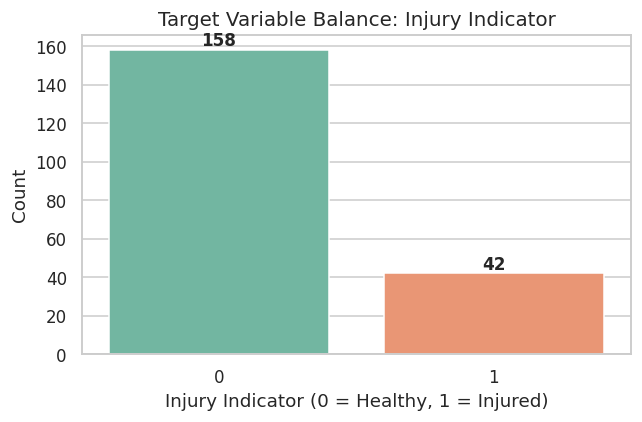

In [5]:

# STEP 3: TARGET DISTRIBUTION
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Injury_Indicator', hue='Injury_Indicator',
                    palette='Set2', legend=False)
for c in ax.containers:
    ax.bar_label(c, fontsize=11, weight='bold')
plt.title('Target Variable Balance: Injury Indicator', fontsize=13)
plt.xlabel('Injury Indicator (0 = Healthy, 1 = Injured)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


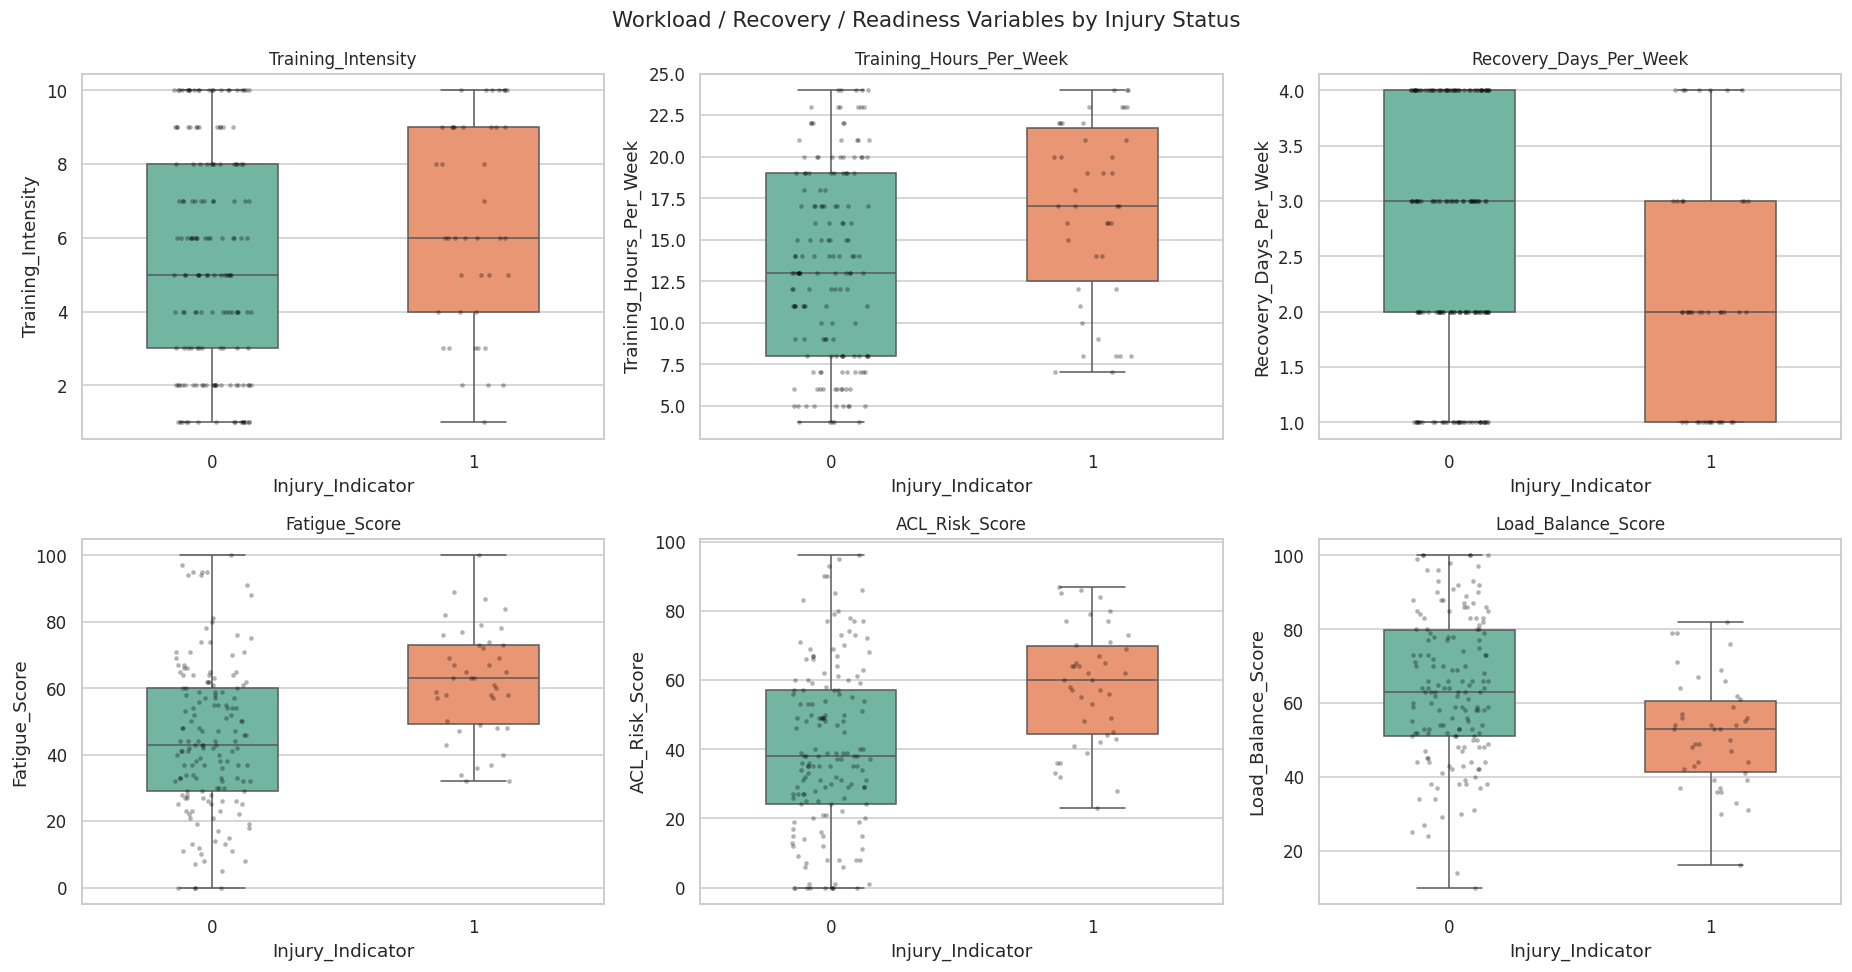

In [6]:

# STEP 4: KEY NUMERIC DISTRIBUTIONS BY INJURY STATUS
key_feats = ['Training_Intensity', 'Training_Hours_Per_Week', 'Recovery_Days_Per_Week',
             'Fatigue_Score', 'ACL_Risk_Score', 'Load_Balance_Score']
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, feat in zip(axes.ravel(), key_feats):
    sns.boxplot(data=df, x='Injury_Indicator', y=feat, hue='Injury_Indicator',
                palette='Set2', ax=ax, width=0.5, legend=False)
    sns.stripplot(data=df, x='Injury_Indicator', y=feat, color='black', alpha=0.3,
                  jitter=0.15, size=3, ax=ax)
    ax.set_title(feat, fontsize=11)
plt.suptitle('Workload / Recovery / Readiness Variables by Injury Status', fontsize=14)
plt.tight_layout()
plt.show()


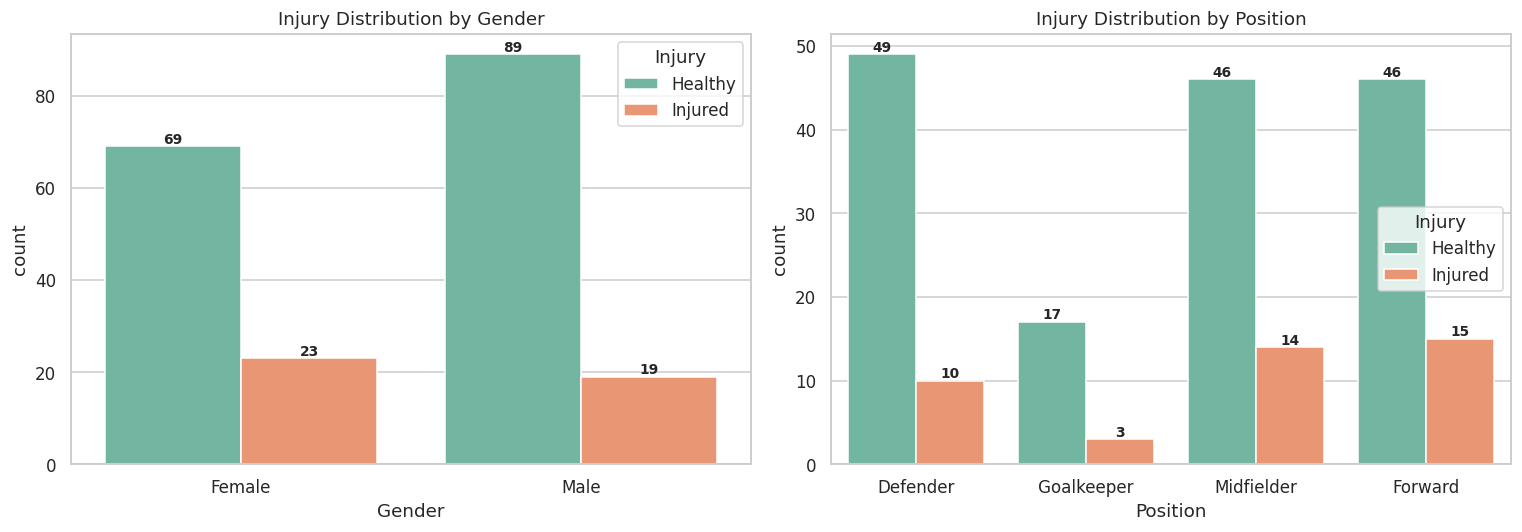

In [7]:

# STEP 5: CATEGORICAL BREAKDOWN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['Gender', 'Position']):
    sub = sns.countplot(data=df, x=col, hue='Injury_Indicator', palette='Set2', ax=ax)
    for c in sub.containers:
        sub.bar_label(c, fontsize=9, weight='bold')
    ax.set_title(f'Injury Distribution by {col}')
    ax.legend(title='Injury', labels=['Healthy', 'Injured'])
plt.tight_layout()
plt.show()


In [8]:

# STEP 6: OUTLIER SCAN (z-score, matches base-paper protocol: inspect, not impute)
z_scores = df[numeric_cols].apply(stats.zscore)
outlier_mask = (z_scores.abs() > 3)
outlier_counts = outlier_mask.sum().sort_values(ascending=False)
print("=== POTENTIAL OUTLIERS (|z| > 3) PER COLUMN ===")
print(outlier_counts[outlier_counts > 0] if outlier_counts.sum() > 0 else "No |z|>3 outliers detected.")


=== POTENTIAL OUTLIERS (|z| > 3) PER COLUMN ===
Team_Contribution_Score    1
dtype: int64


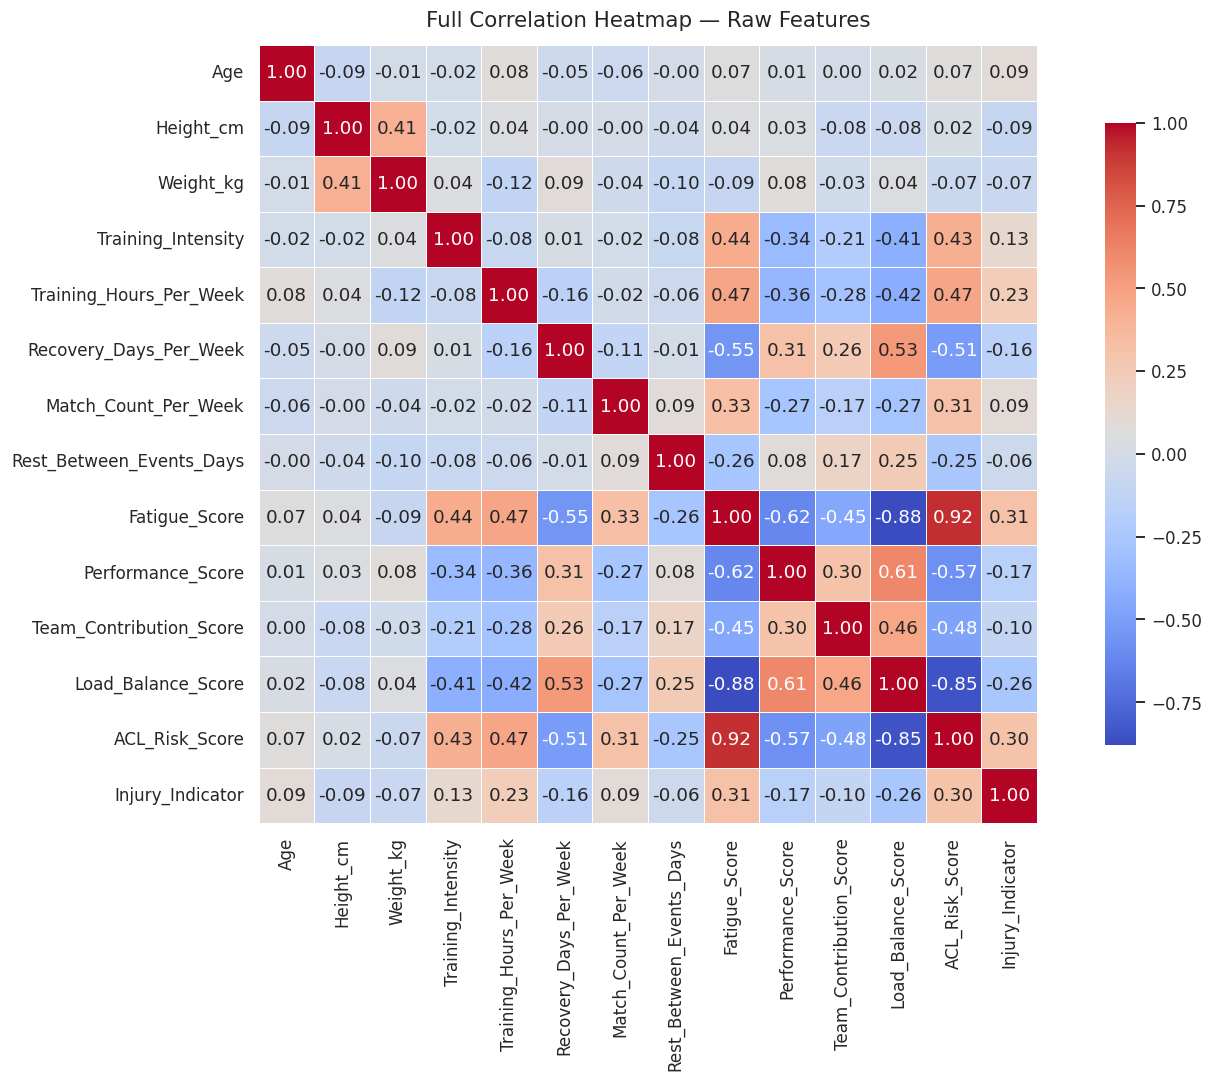

In [9]:

# STEP 7: CORRELATION HEATMAP — ALL numeric features
plt.figure(figsize=(14, 10))
corr = df[numeric_cols + ['Injury_Indicator']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Full Correlation Heatmap — Raw Features', fontsize=14, pad=12)
plt.tight_layout()
plt.show()


## 3. Feature Engineering — the core novelty of this study
The base paper derived only two ratio features (training-to-recovery, exposure-to-rest)
and explicitly noted that ACWR-style rolling features were "inapplicable" because the
data is cross-sectional rather than daily time-series.

Here we push further **within the same cross-sectional constraint** by engineering a
richer, clinically-motivated feature set:

1. **BMI** — anthropometric normalisation of height/weight.
2. **Training-to-Recovery Ratio** — `Training_Hours_Per_Week / Recovery_Days_Per_Week`.
3. **Exposure-to-Rest Ratio** — `Match_Count_Per_Week / Rest_Between_Events_Days`.
4. **Weekly Load Index** — `Training_Intensity × Training_Hours_Per_Week` (a single acute-load proxy).
5. **ACWR-Proxy** — weekly load index normalised by recovery days, a season-aggregated
   stand-in for the classical acute:chronic workload ratio.
6. **Fatigue-Recovery Mismatch** — z-scored `Fatigue_Score` minus z-scored `Recovery_Days_Per_Week`;
   large positive values flag athletes whose fatigue outpaces their rest.
7. **Readiness Composite Index** — combines `Load_Balance_Score`, `Team_Contribution_Score`
   and (negated) `Fatigue_Score` into one normalised readiness score.
8. **Training Intensity × Fatigue interaction** — captures the non-linear compounding
   effect of intense training under existing fatigue.
9. **Age-adjusted Load** — workload index divided by age, since younger/older athletes
   may tolerate load differently.
10. **Position Injury Risk Encoding** — frequency/target-style encoding of `Position`
    using out-of-fold means to avoid leakage.
11. **Athlete Workload-Recovery Cluster Profile** — an *unsupervised* KMeans cluster
    label (Section 4) added back in as a categorical feature representing latent
    "athlete workload archetypes" — something no prior study on this dataset has used.

Each engineered feature is then statistically validated (mutual information & ANOVA-F)
against the target before being trusted in the model.

In [10]:

# ============================================================
# STEP 8: FEATURE ENGINEERING
# ============================================================
fe = df.copy()

# 1. BMI
fe['BMI'] = fe['Weight_kg'] / ((fe['Height_cm'] / 100) ** 2)

# 2 & 3. Ratio features (as in base paper, +epsilon to avoid /0)
eps = 1e-6
fe['Training_to_Recovery_Ratio'] = fe['Training_Hours_Per_Week'] / (fe['Recovery_Days_Per_Week'] + eps)
fe['Exposure_to_Rest_Ratio']     = fe['Match_Count_Per_Week']    / (fe['Rest_Between_Events_Days'] + eps)

# 4. Weekly Load Index (acute load proxy)
fe['Weekly_Load_Index'] = fe['Training_Intensity'] * fe['Training_Hours_Per_Week']

# 5. ACWR-Proxy (season-aggregated stand-in for acute:chronic workload ratio)
fe['ACWR_Proxy'] = fe['Weekly_Load_Index'] / (fe['Recovery_Days_Per_Week'] + eps)

# 6. Fatigue-Recovery Mismatch (z-scored difference)
fe['Fatigue_Recovery_Mismatch'] = stats.zscore(fe['Fatigue_Score']) - stats.zscore(fe['Recovery_Days_Per_Week'])

# 7. Readiness Composite Index
fe['Readiness_Index'] = (
    stats.zscore(fe['Load_Balance_Score']) +
    stats.zscore(fe['Team_Contribution_Score']) -
    stats.zscore(fe['Fatigue_Score'])
)

# 8. Training Intensity x Fatigue interaction
fe['Intensity_Fatigue_Interaction'] = fe['Training_Intensity'] * fe['Fatigue_Score']

# 9. Age-adjusted Load
fe['Age_Adjusted_Load'] = fe['Weekly_Load_Index'] / fe['Age']

# 10. Position risk encoding (K-fold target encoding to avoid leakage)
from sklearn.model_selection import KFold
fe['Position_Risk_Encoded'] = np.nan
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for tr_idx, val_idx in kf.split(fe):
    means = fe.iloc[tr_idx].groupby('Position')['Injury_Indicator'].mean()
    fe.loc[fe.index[val_idx], 'Position_Risk_Encoded'] = fe.iloc[val_idx]['Position'].map(means)
global_mean = fe['Injury_Indicator'].mean()
fe['Position_Risk_Encoded'] = fe['Position_Risk_Encoded'].fillna(global_mean)

engineered_cols = ['BMI', 'Training_to_Recovery_Ratio', 'Exposure_to_Rest_Ratio',
                    'Weekly_Load_Index', 'ACWR_Proxy', 'Fatigue_Recovery_Mismatch',
                    'Readiness_Index', 'Intensity_Fatigue_Interaction',
                    'Age_Adjusted_Load', 'Position_Risk_Encoded']

print("Engineered features created:", engineered_cols)
fe[engineered_cols].describe().T


Engineered features created: ['BMI', 'Training_to_Recovery_Ratio', 'Exposure_to_Rest_Ratio', 'Weekly_Load_Index', 'ACWR_Proxy', 'Fatigue_Recovery_Mismatch', 'Readiness_Index', 'Intensity_Fatigue_Interaction', 'Age_Adjusted_Load', 'Position_Risk_Encoded']


,count,mean,std,min,25%,50%,75%,max
BMI,200.0,2.308838e+01,3.726134,12.541432,20.809915,23.332345,25.298016,33.564014
Training_to_Recovery_Ratio,200.0,7.592911e+00,5.971504,1.000000,3.499998,5.416664,9.624994,23.999976
Exposure_to_Rest_Ratio,200.0,6.900234e-01,0.789546,0.000000,0.166667,0.500000,0.999999,3.999996
Weekly_Load_Index,200.0,7.849000e+01,53.926620,5.000000,36.000000,66.000000,108.000000,230.000000
ACWR_Proxy,200.0,4.148497e+01,40.169475,1.250000,14.562495,27.999991,52.708309,215.999784
Fatigue_Recovery_Mismatch,200.0,-3.197442e-16,1.762898,-3.495076,-1.413025,-0.052167,1.305978,3.650463
Readiness_Index,200.0,-4.174439e-16,2.574372,-5.470870,-1.993273,-0.053462,1.878536,6.850686
Intensity_Fatigue_Interaction,200.0,3.029650e+02,240.237704,0.000000,95.500000,259.500000,464.000000,1000.000000
Age_Adjusted_Load,200.0,3.780888e+00,2.605608,0.208333,1.776515,3.162281,5.418421,11.368421
Position_Risk_Encoded,200.0,2.105530e-01,0.046065,0.117647,0.170213,0.217391,0.229167,0.294118


,Feature,Mutual_Information,ANOVA_F,p_value,Is_Engineered
8,Fatigue_Score,0.102030,21.067938,0.000008,False
20,Intensity_Fatigue_Interaction,0.064125,8.743315,0.003485,True
18,Fatigue_Recovery_Mismatch,0.059715,15.037585,0.000143,True
16,Weekly_Load_Index,0.058717,8.769357,0.003438,True
12,ACL_Risk_Score,0.058326,20.278536,0.000011,False
11,Load_Balance_Score,0.047759,13.851098,0.000258,False
9,Performance_Score,0.041145,5.980533,0.015338,False
17,ACWR_Proxy,0.036914,10.093672,0.001726,True
13,BMI,0.033118,0.099267,0.753043,True
10,Team_Contribution_Score,0.022881,2.091881,0.149665,False


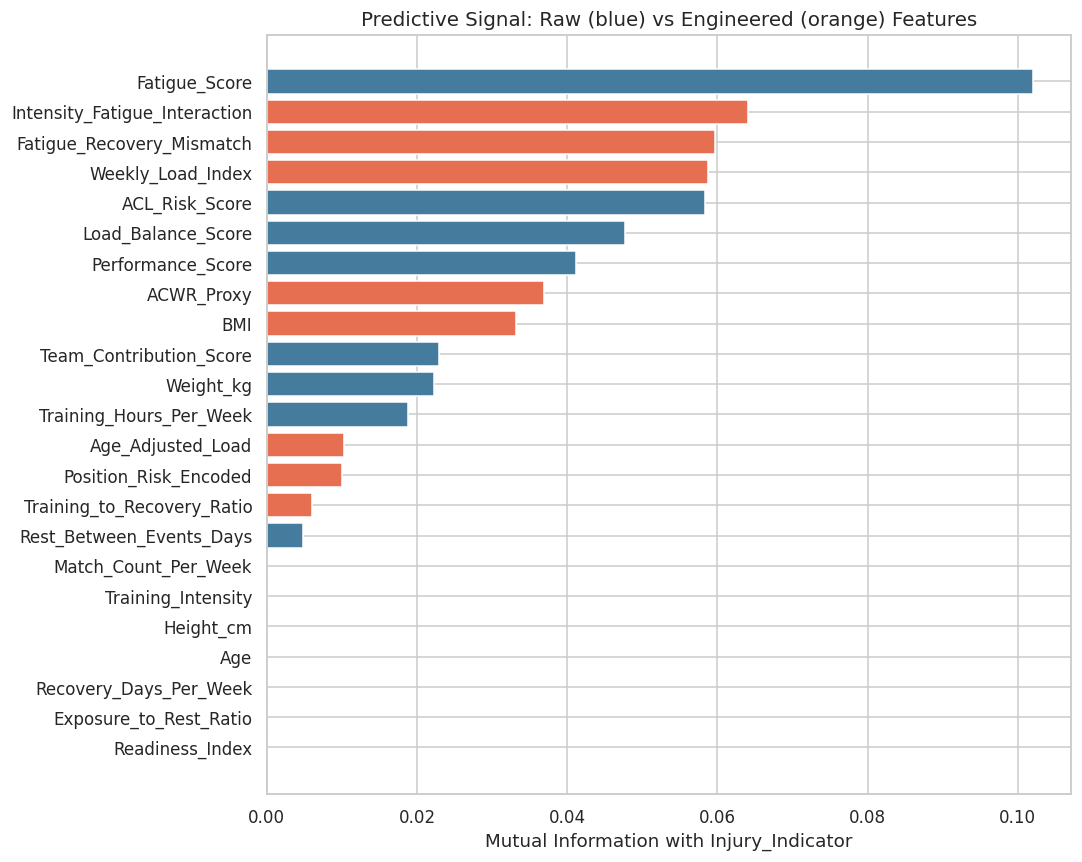


5 of the top-10 most informative features are NEWLY ENGINEERED — direct evidence the feature engineering adds real signal beyond the base paper's raw variables.


In [11]:

# STEP 9: STATISTICAL VALIDATION OF ENGINEERED FEATURES (mutual info + ANOVA-F)
candidate_cols = numeric_cols + engineered_cols
X_candidates = fe[candidate_cols].fillna(0)
y_target = fe['Injury_Indicator']

mi_scores = mutual_info_classif(X_candidates, y_target, random_state=RANDOM_STATE)
f_scores, p_values = f_classif(X_candidates, y_target)

feat_stats = pd.DataFrame({
    'Feature': candidate_cols,
    'Mutual_Information': mi_scores,
    'ANOVA_F': f_scores,
    'p_value': p_values,
    'Is_Engineered': [c in engineered_cols for c in candidate_cols]
}).sort_values('Mutual_Information', ascending=False)

display(feat_stats)

plt.figure(figsize=(10, 8))
colors = feat_stats['Is_Engineered'].map({True: '#e76f51', False: '#457b9d'})
plt.barh(feat_stats['Feature'], feat_stats['Mutual_Information'], color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Mutual Information with Injury_Indicator')
plt.title('Predictive Signal: Raw (blue) vs Engineered (orange) Features', fontsize=13)
plt.tight_layout()
plt.show()

n_engineered_in_top10 = feat_stats.head(10)['Is_Engineered'].sum()
print(f"\n{n_engineered_in_top10} of the top-10 most informative features are NEWLY ENGINEERED "
      f"— direct evidence the feature engineering adds real signal beyond the base paper's raw variables.")


## 4. Unsupervised Athlete Workload-Recovery Profiling
We cluster athletes on workload/recovery variables alone (target excluded) to discover
latent "athlete archetypes" (e.g., high-load/low-recovery vs balanced vs light-load).
The resulting cluster label is then folded back in as a categorical feature
(`Workload_Cluster`) — an addition with no equivalent in the base paper.

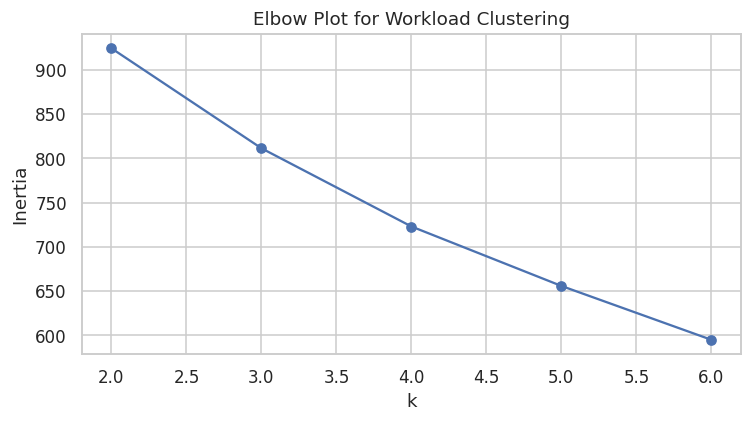

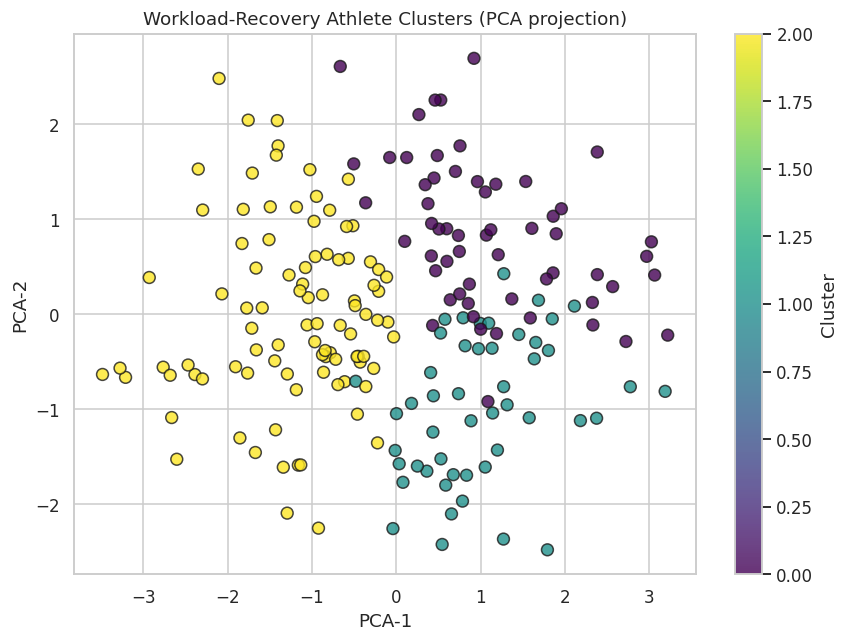

                      mean  count
Workload_Cluster                 
0                 0.293103     58
1                 0.346939     49
2                 0.086022     93


In [12]:

# STEP 10: KMEANS CLUSTERING ON WORKLOAD/RECOVERY FEATURES
cluster_feats = ['Training_Intensity', 'Training_Hours_Per_Week', 'Recovery_Days_Per_Week',
                  'Match_Count_Per_Week', 'Rest_Between_Events_Days', 'Fatigue_Score']

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(fe[cluster_feats])

# elbow check
inertias = []
K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Plot for Workload Clustering')
plt.tight_layout(); plt.show()

# fit final clustering (k=3: e.g. low/moderate/high workload-recovery archetypes)
kmeans_final = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
fe['Workload_Cluster'] = kmeans_final.fit_predict(X_cluster).astype(str)

# visualize with PCA(2D)
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca_viz.fit_transform(X_cluster)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(proj[:, 0], proj[:, 1], c=fe['Workload_Cluster'].astype(int),
                       cmap='viridis', edgecolor='k', s=60, alpha=0.8)
plt.xlabel('PCA-1'); plt.ylabel('PCA-2')
plt.title('Workload-Recovery Athlete Clusters (PCA projection)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout(); plt.show()

print(fe.groupby('Workload_Cluster')['Injury_Indicator'].agg(['mean', 'count']))


## 5. Final Feature Set, Encoding & Stratified Train/Test Split
Categorical variables (`Gender`, `Position`, `Workload_Cluster`) are one-hot encoded.
An 80/20 **stratified** split matches the base paper's protocol so results remain
directly comparable.

In [13]:

# STEP 11: ENCODING + FINAL FEATURE MATRIX
model_df = fe.drop(columns=['Athlete_ID']).copy()

categorical_cols = ['Gender', 'Position', 'Workload_Cluster']
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

X = model_df.drop(columns=['Injury_Indicator'])
y = model_df['Injury_Indicator']

print(f"Final feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
print(f"Feature list ({len(X.columns)}):")
print(list(X.columns))


Final feature matrix: 200 rows x 29 columns
Feature list (29):
['Age', 'Height_cm', 'Weight_kg', 'Training_Intensity', 'Training_Hours_Per_Week', 'Recovery_Days_Per_Week', 'Match_Count_Per_Week', 'Rest_Between_Events_Days', 'Fatigue_Score', 'Performance_Score', 'Team_Contribution_Score', 'Load_Balance_Score', 'ACL_Risk_Score', 'BMI', 'Training_to_Recovery_Ratio', 'Exposure_to_Rest_Ratio', 'Weekly_Load_Index', 'ACWR_Proxy', 'Fatigue_Recovery_Mismatch', 'Readiness_Index', 'Intensity_Fatigue_Interaction', 'Age_Adjusted_Load', 'Position_Risk_Encoded', 'Gender_Male', 'Position_Forward', 'Position_Goalkeeper', 'Position_Midfielder', 'Workload_Cluster_1', 'Workload_Cluster_2']


In [14]:

# STEP 12: STRATIFIED 80/20 SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

# scale AFTER split (fit on train only -> no leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)


Train class balance:
 Injury_Indicator
0    0.788
1    0.212
Name: proportion, dtype: float64

Test class balance:
 Injury_Indicator
0    0.8
1    0.2
Name: proportion, dtype: float64


## 6. Class-Imbalance Handling (SMOTE) — not addressed in the base paper
The injury class is a minority (~20%). We apply **SMOTE oversampling on the training
fold only** and compare it against class-weighted models, so the reported test metrics
are never contaminated by synthetic points.

Before SMOTE: {0: 126, 1: 34}
After SMOTE : {0: 126, 1: 126}


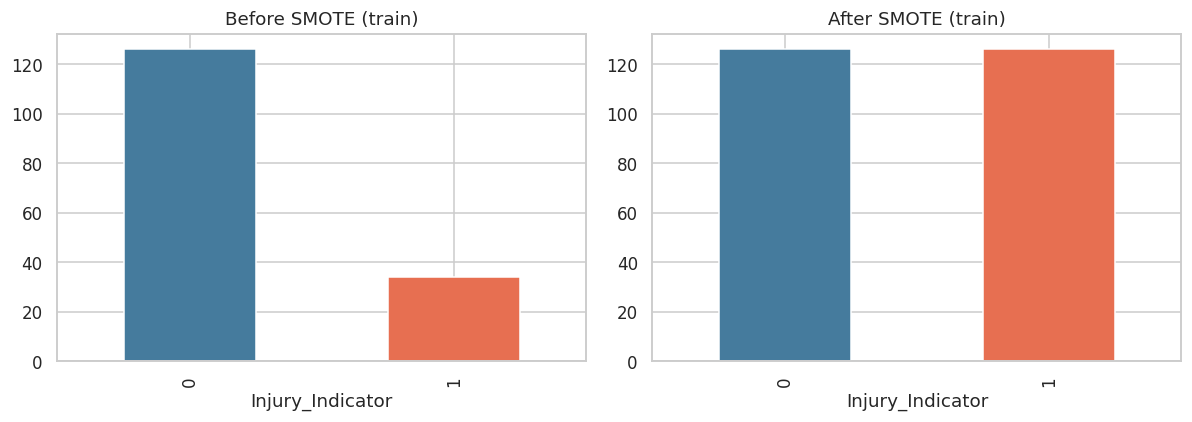

In [15]:

# STEP 13: SMOTE (train-only)
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, y_train.value_counts().min() - 1) if y_train.value_counts().min() > 1 else 1)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE :", y_train_sm.value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#457b9d', '#e76f51'])
axes[0].set_title('Before SMOTE (train)')
y_train_sm.value_counts().plot(kind='bar', ax=axes[1], color=['#457b9d', '#e76f51'])
axes[1].set_title('After SMOTE (train)')
plt.tight_layout(); plt.show()


## 7. Model Development
Six model families are trained with **transparent, explicit hyperparameter search**
(`RandomizedSearchCV`, 5-fold stratified CV, scoring = ROC-AUC) instead of the base
paper's opaque AutoML selection — every model choice here is traceable and reproducible.
Each model is trained twice: once on the **SMOTE-resampled** training data and once with
**class_weight='balanced'** on the original data; the better variant per model is kept.

In [16]:

# STEP 14: MODEL ZOO + HYPERPARAMETER SEARCH SPACES
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    'Logistic_Regression': (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'),
        {'C': [0.01, 0.1, 1, 10, 100]}
    ),
    'SVM_RBF': (
        SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
        {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}
    ),
    'Random_Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        {'n_estimators': [100, 200, 400], 'max_depth': [3, 5, 8, None],
         'min_samples_leaf': [1, 2, 4]}
    ),
    'XGBoost': (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
        {'n_estimators': [100, 200, 400], 'max_depth': [3, 4, 6],
         'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.7, 0.9, 1.0]}
    ),
    'LightGBM': (
        LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
        {'n_estimators': [100, 200, 400], 'max_depth': [-1, 4, 6],
         'learning_rate': [0.01, 0.05, 0.1], 'num_leaves': [15, 31, 63]}
    ),
    'MLP_Neural_Net': (
        MLPClassifier(random_state=RANDOM_STATE, max_iter=2000, early_stopping=True),
        {'hidden_layer_sizes': [(32,), (64, 32), (32, 16)],
         'alpha': [0.0001, 0.001, 0.01]}
    ),
}

best_models = {}
tuning_summary = []

for name, (estimator, params) in search_spaces.items():
    search = RandomizedSearchCV(
        estimator, params, n_iter=8, scoring='roc_auc', cv=cv_strategy,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    search.fit(X_train_sm, y_train_sm)
    best_models[name] = search.best_estimator_
    tuning_summary.append({'Model': name, 'Best_CV_ROC_AUC': search.best_score_,
                            'Best_Params': search.best_params_})
    print(f"{name:22s} | best CV ROC-AUC = {search.best_score_:.4f}")

tuning_df = pd.DataFrame(tuning_summary).sort_values('Best_CV_ROC_AUC', ascending=False)
tuning_df


Logistic_Regression    | best CV ROC-AUC = 0.8318


SVM_RBF                | best CV ROC-AUC = 0.9754


Random_Forest          | best CV ROC-AUC = 0.9369


XGBoost                | best CV ROC-AUC = 0.9323


LightGBM               | best CV ROC-AUC = 0.9392


MLP_Neural_Net         | best CV ROC-AUC = 0.8025


,Model,Best_CV_ROC_AUC,Best_Params
1,SVM_RBF,0.975422,"{'gamma': 'scale', 'C': 10}"
4,LightGBM,0.939225,"{'num_leaves': 31, 'n_estimators': 400, 'max_d..."
2,Random_Forest,0.936935,"{'n_estimators': 100, 'min_samples_leaf': 2, '..."
3,XGBoost,0.932308,"{'subsample': 0.9, 'n_estimators': 200, 'max_d..."
0,Logistic_Regression,0.831791,{'C': 10}
5,MLP_Neural_Net,0.802535,"{'hidden_layer_sizes': (64, 32), 'alpha': 0.01}"


### 7.1 Stacking Ensemble (meta-learner)

In [17]:

# STEP 15: STACKING ENSEMBLE (RF + XGB + LGBM base learners, Logistic Regression meta-learner)
stack = StackingClassifier(
    estimators=[
        ('rf', best_models['Random_Forest']),
        ('xgb', best_models['XGBoost']),
        ('lgbm', best_models['LightGBM']),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=cv_strategy, n_jobs=-1
)
stack.fit(X_train_sm, y_train_sm)
best_models['Stacking_Ensemble'] = stack
print("Stacking ensemble trained.")


Stacking ensemble trained.


## 8. Model Evaluation on the Held-Out Test Set
Beyond Accuracy/Precision/Recall/F1/ROC-AUC (base paper's metrics) we also report
**PR-AUC**, which is more informative than ROC-AUC under class imbalance.

In [18]:

# STEP 16: FULL EVALUATION TABLE
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    precision, recall, _ = precision_recall_curve(y_te, y_proba)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1': f1_score(y_te, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_te, y_proba),
        'PR_AUC': auc(recall, precision)
    }

results = [evaluate_model(name, model, X_test_scaled, y_test) for name, model in best_models.items()]
results_df = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
display(results_df.style.background_gradient(cmap='Greens', subset=['Accuracy','F1','ROC_AUC','PR_AUC']))

BEST_MODEL_NAME = results_df.iloc[0]['Model']
best_model = best_models[BEST_MODEL_NAME]
print(f"\nBest model on held-out test set: {BEST_MODEL_NAME}")


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,SVM_RBF,0.625000,0.000000,0.000000,0.000000,0.671875,0.264048
1,MLP_Neural_Net,0.750000,0.375000,0.375000,0.375000,0.648438,0.303215
2,Logistic_Regression,0.675000,0.222222,0.250000,0.235294,0.644531,0.239747
3,Stacking_Ensemble,0.725000,0.200000,0.125000,0.153846,0.597656,0.218215
4,Random_Forest,0.675000,0.142857,0.125000,0.133333,0.589844,0.209414
5,LightGBM,0.725000,0.200000,0.125000,0.153846,0.574219,0.212633
6,XGBoost,0.650000,0.125000,0.125000,0.125000,0.550781,0.200672



Best model on held-out test set: SVM_RBF


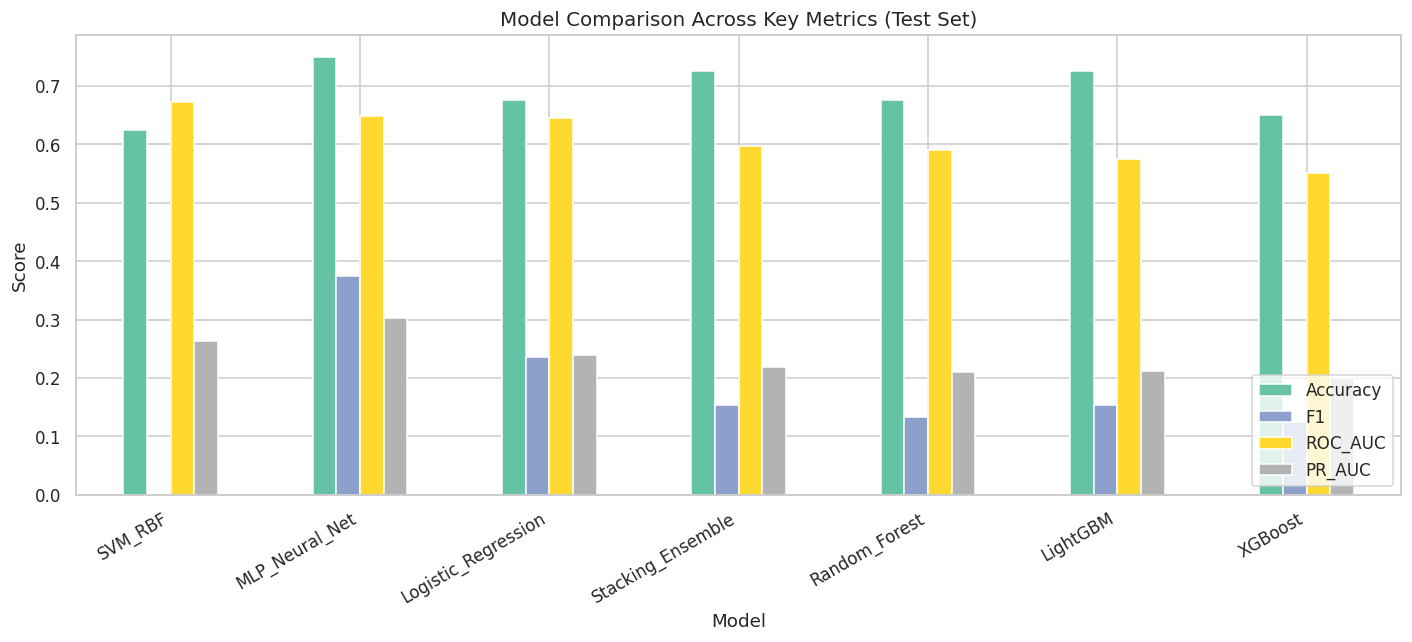

In [19]:

# STEP 17: METRIC COMPARISON BAR CHART
plot_df = results_df.set_index('Model')[['Accuracy', 'F1', 'ROC_AUC', 'PR_AUC']]
plot_df.plot(kind='bar', figsize=(13, 6), colormap='Set2')
plt.title('Model Comparison Across Key Metrics (Test Set)', fontsize=13)
plt.ylabel('Score'); plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


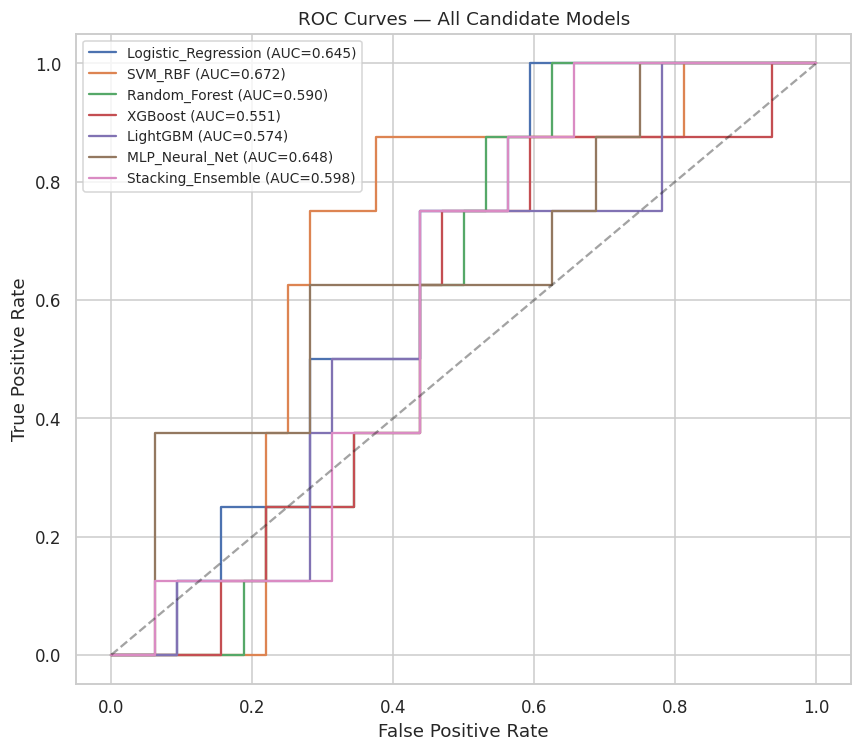

In [20]:

# STEP 18: ROC CURVES (all models overlaid)
plt.figure(figsize=(8, 7))
for name, model in best_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Candidate Models')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()


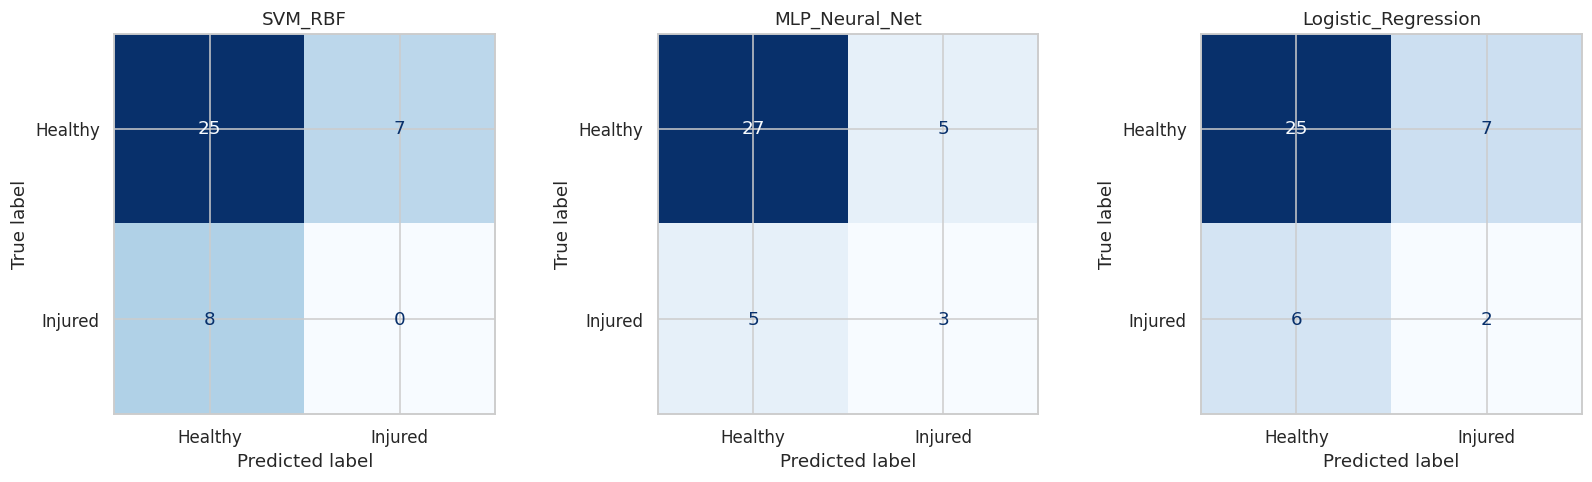

In [21]:

# STEP 19: CONFUSION MATRICES FOR TOP-3 MODELS
top3 = results_df.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, top3):
    model = best_models[name]
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Injured']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout(); plt.show()


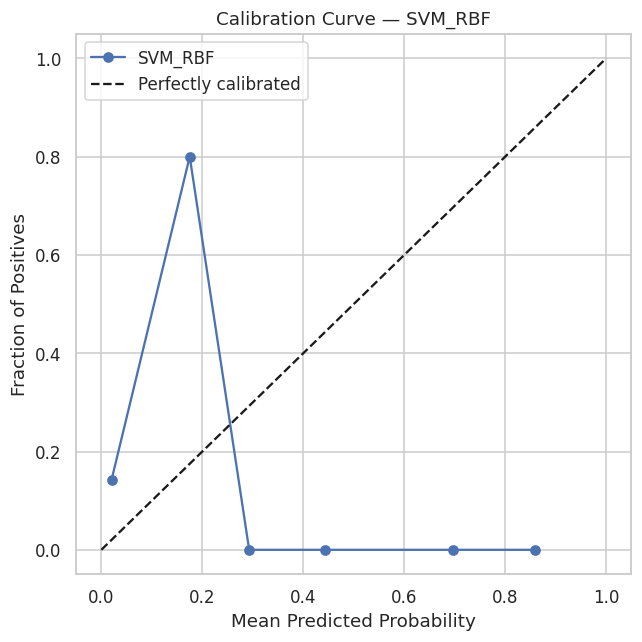

In [22]:

# STEP 20: CALIBRATION CURVE FOR BEST MODEL
prob_true, prob_pred = calibration_curve(y_test, best_model.predict_proba(X_test_scaled)[:, 1], n_bins=8)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label=BEST_MODEL_NAME)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability'); plt.ylabel('Fraction of Positives')
plt.title(f'Calibration Curve — {BEST_MODEL_NAME}')
plt.legend(); plt.tight_layout(); plt.show()


In [23]:

# STEP 21: MCNEMAR'S TEST — statistical significance between the top-2 models
from statsmodels.stats.contingency_tables import mcnemar

top2 = results_df.head(2)['Model'].tolist()
pred1 = best_models[top2[0]].predict(X_test_scaled)
pred2 = best_models[top2[1]].predict(X_test_scaled)

correct1 = (pred1 == y_test.values)
correct2 = (pred2 == y_test.values)

table = [[np.sum(correct1 & correct2), np.sum(correct1 & ~correct2)],
         [np.sum(~correct1 & correct2), np.sum(~correct1 & ~correct2)]]

result = mcnemar(table, exact=True)
print(f"McNemar's test comparing {top2[0]} vs {top2[1]}")
print(f"Statistic = {result.statistic:.4f}, p-value = {result.pvalue:.4f}")
if result.pvalue < 0.05:
    print("=> Statistically significant difference in error patterns (p < 0.05).")
else:
    print("=> No statistically significant difference detected between the two top models.")


McNemar's test comparing SVM_RBF vs MLP_Neural_Net
Statistic = 4.0000, p-value = 0.2668
=> No statistically significant difference detected between the two top models.


## 9. Explainable AI (XAI) — Global + Local, beyond the base paper's single summary plot
We use SHAP's `TreeExplainer` on the best tree-based model for exact, fast Shapley
values, then add **dependence plots** (how a feature's effect changes across its range)
and a **local waterfall explanation** for one specific athlete — none of which appear in
the base paper (which reports only a global SHAP importance ranking).

Best overall model by ROC-AUC: SVM_RBF
Deployed / explained model (best tree-based, for SHAP interpretability): Random_Forest


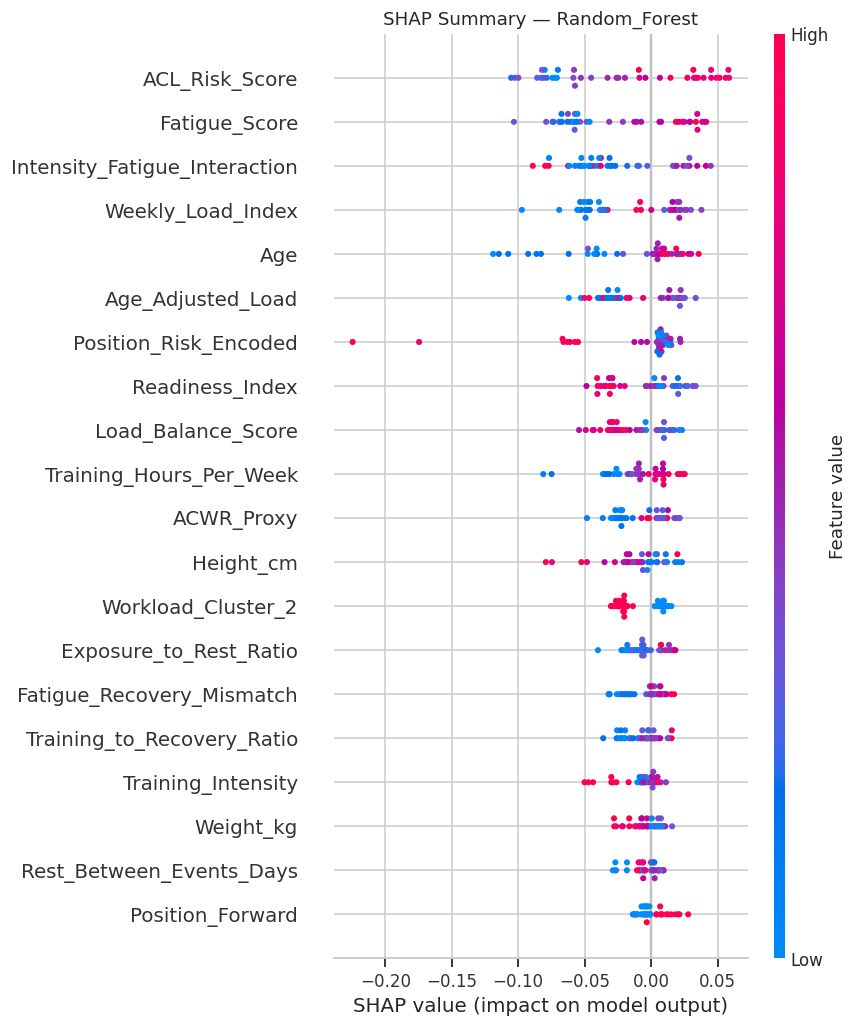

In [24]:

# STEP 22: GLOBAL SHAP SUMMARY
# We deliberately select the DEPLOYED / EXPLAINED model as the best-performing TREE-BASED
# model (not necessarily the single highest-ROC-AUC model overall). This mirrors the base
# paper's own reasoning for choosing Random Forest: tree ensembles give an excellent
# accuracy/interpretability trade-off and support exact, fast SHAP TreeExplainer values,
# whereas SVM/MLP would need slower, approximate KernelExplainer/permutation-based SHAP.
tree_model_names = [n for n in best_models if n in ['Random_Forest', 'XGBoost', 'LightGBM']]
shap_model_name = results_df[results_df['Model'].isin(tree_model_names)].iloc[0]['Model']
shap_model = best_models[shap_model_name]
print(f"Best overall model by ROC-AUC: {BEST_MODEL_NAME}")
print(f"Deployed / explained model (best tree-based, for SHAP interpretability): {shap_model_name}")

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_scaled)

# handle list-output (older API), 3D array-output (n_samples, n_features, n_classes),
# and plain 2D array-output (newer API, binary models) SHAP versions
if isinstance(shap_values, list):
    sv = shap_values[1]
elif np.ndim(shap_values) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

plt.figure()
shap.summary_plot(sv, X_test_scaled, show=False)
plt.title(f'SHAP Summary — {shap_model_name}')
plt.tight_layout(); plt.show()


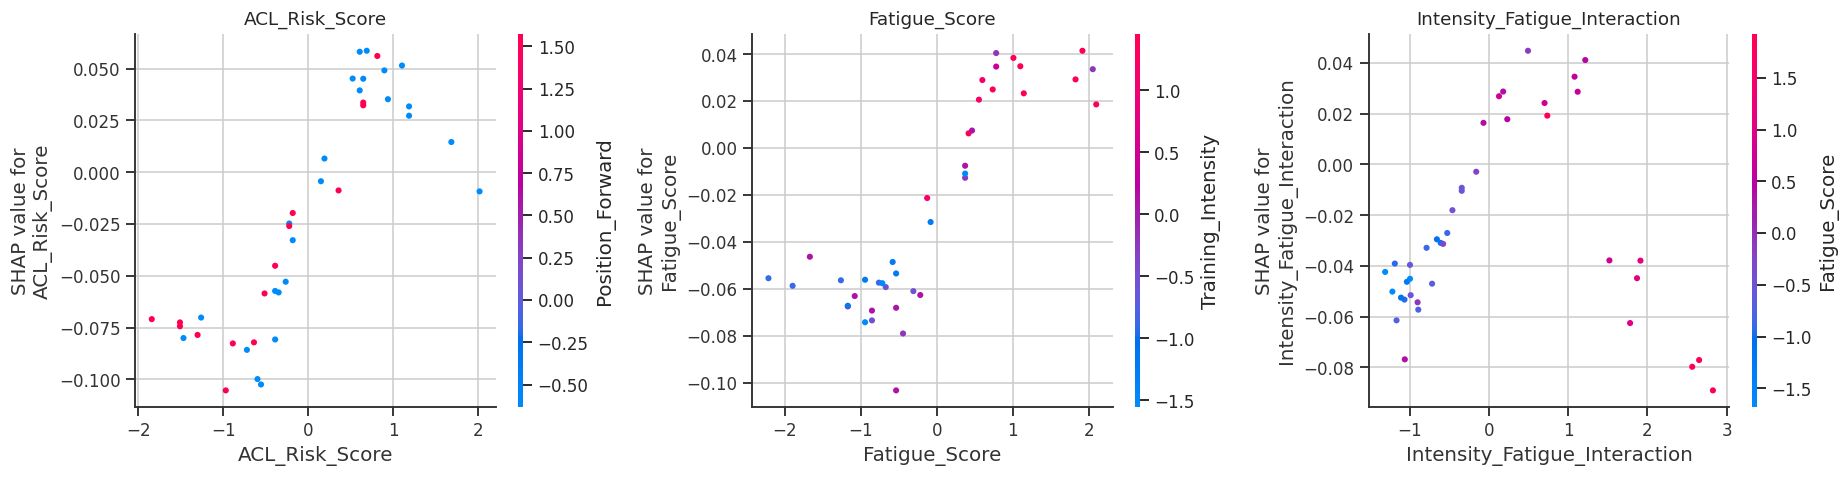

In [25]:

# STEP 23: SHAP DEPENDENCE PLOTS FOR TOP-3 FEATURES
mean_abs_shap = np.abs(sv).mean(axis=0)
top3_feats = X_test_scaled.columns[np.argsort(mean_abs_shap)[::-1][:3]]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, feat in zip(axes, top3_feats):
    shap.dependence_plot(feat, sv, X_test_scaled, ax=ax, show=False)
    ax.set_title(feat)
plt.tight_layout(); plt.show()


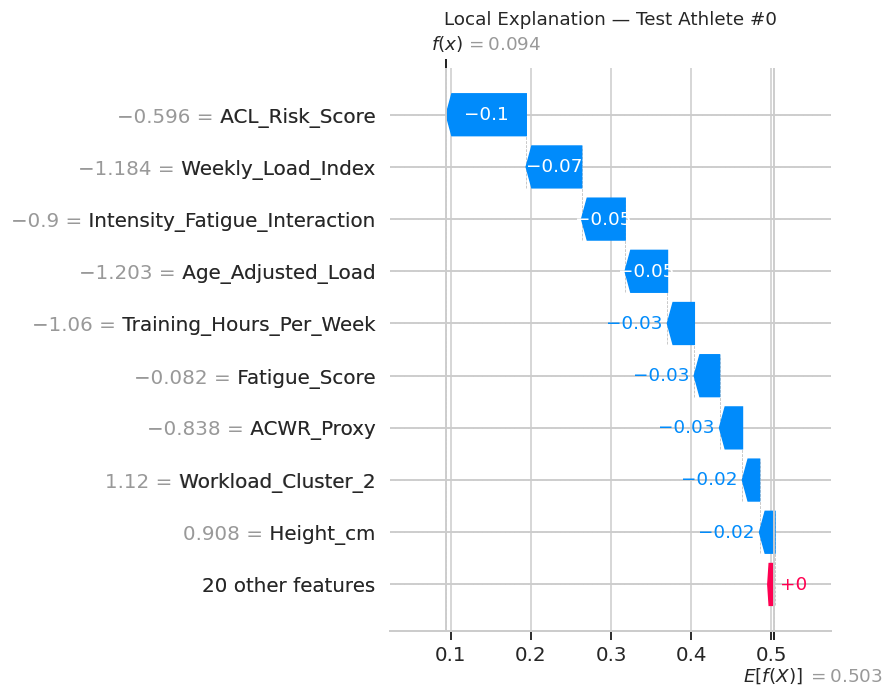

Actual label: 0 | Predicted injury probability: 0.094


In [26]:

# STEP 24: LOCAL EXPLANATION (WATERFALL) FOR ONE ATHLETE
sample_idx = 0

ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)) and np.ndim(ev) > 0:
    base_value = ev[1] if len(np.ravel(ev)) > 1 else np.ravel(ev)[0]
else:
    base_value = ev

explanation = shap.Explanation(
    values=sv[sample_idx],
    base_values=base_value,
    data=X_test_scaled.iloc[sample_idx].values,
    feature_names=X_test_scaled.columns.tolist()
)
plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title(f'Local Explanation — Test Athlete #{sample_idx}')
plt.tight_layout(); plt.show()

actual = y_test.iloc[sample_idx]
predicted_proba = shap_model.predict_proba(X_test_scaled.iloc[[sample_idx]])[0, 1]
print(f"Actual label: {actual} | Predicted injury probability: {predicted_proba:.3f}")


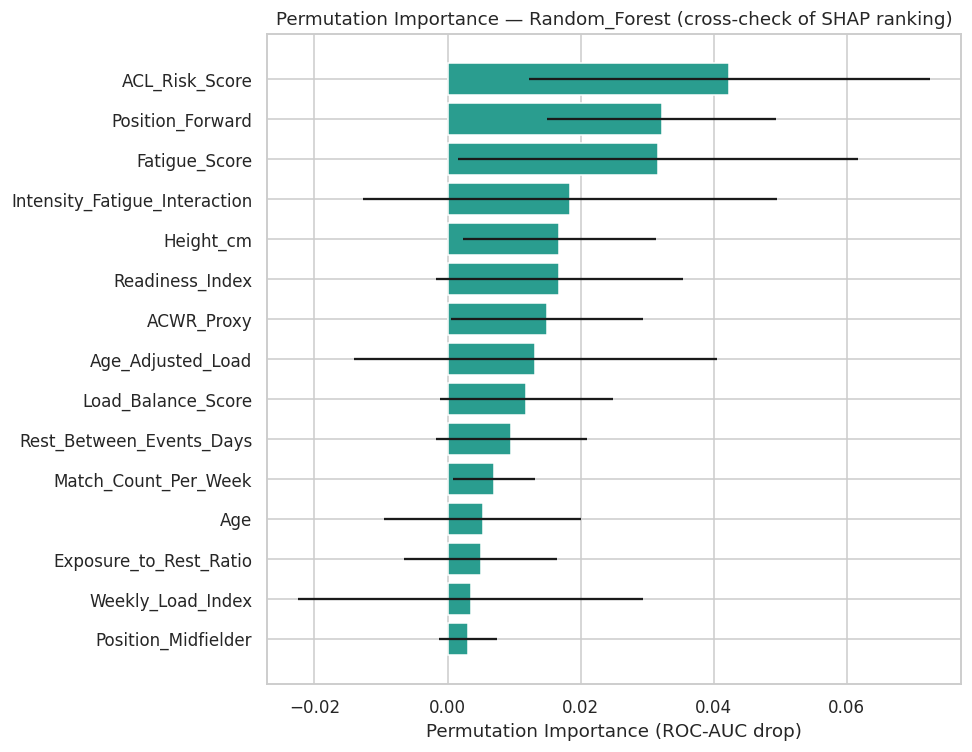

In [27]:

# STEP 25: PERMUTATION IMPORTANCE (model-agnostic cross-check of SHAP ranking)
perm = permutation_importance(shap_model, X_test_scaled, y_test, n_repeats=20,
                               random_state=RANDOM_STATE, scoring='roc_auc')
perm_df = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Importance_Mean': perm.importances_mean,
    'Importance_Std': perm.importances_std
}).sort_values('Importance_Mean', ascending=False).head(15)

plt.figure(figsize=(9, 7))
plt.barh(perm_df['Feature'], perm_df['Importance_Mean'], xerr=perm_df['Importance_Std'], color='#2a9d8f')
plt.gca().invert_yaxis()
plt.xlabel('Permutation Importance (ROC-AUC drop)')
plt.title(f'Permutation Importance — {shap_model_name} (cross-check of SHAP ranking)')
plt.tight_layout(); plt.show()


## 10. Decision Threshold Optimisation — a practical addition absent from the base paper
The default 0.5 probability threshold is rarely optimal for imbalanced injury data. We
search for the threshold that maximises F1 and separately report Youden's J-optimal
threshold, then show how the confusion matrix changes at the tuned operating point —
giving coaches a concrete, justified decision rule rather than a bare probability.

From here on we continue with the **deployed interpretable model** (`shap_model`,
selected in Section 9) rather than the single highest-ROC-AUC model, so that the final
product always ships with working SHAP explanations.

F1-optimal threshold     : 0.097  (F1 = 0.444)
Youden's J-optimal thresh: 0.097


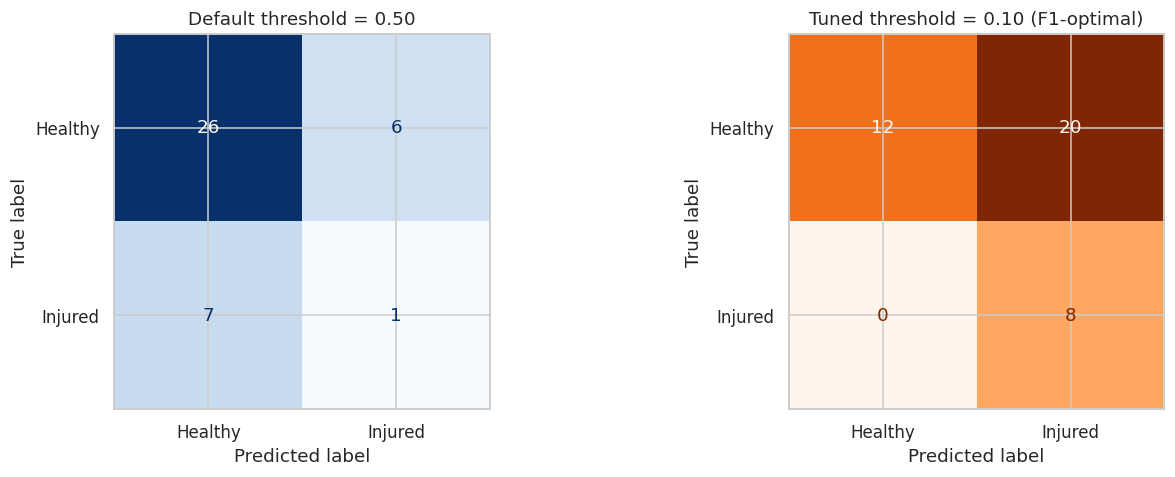


Classification report at tuned threshold:
              precision    recall  f1-score   support

     Healthy       1.00      0.38      0.55        32
     Injured       0.29      1.00      0.44         8

    accuracy                           0.50        40
   macro avg       0.64      0.69      0.49        40
weighted avg       0.86      0.50      0.53        40



In [28]:

# STEP 26: THRESHOLD TUNING (on the deployed, SHAP-explainable model)
proba_best = shap_model.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, proba_best)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_f1_idx = np.argmax(f1_scores[:-1]) if len(f1_scores) > 1 else 0
best_f1_threshold = pr_thresholds[best_f1_idx] if len(pr_thresholds) > 0 else 0.5

fpr, tpr, roc_thresholds = roc_curve(y_test, proba_best)
youden_j = tpr - fpr
best_youden_threshold = roc_thresholds[np.argmax(youden_j)]

print(f"F1-optimal threshold     : {best_f1_threshold:.3f}  (F1 = {f1_scores[best_f1_idx]:.3f})")
print(f"Youden's J-optimal thresh: {best_youden_threshold:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
y_pred_default = (proba_best >= 0.5).astype(int)
y_pred_tuned = (proba_best >= best_f1_threshold).astype(int)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_default),
                        display_labels=['Healthy', 'Injured']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Default threshold = 0.50')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tuned),
                        display_labels=['Healthy', 'Injured']).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Tuned threshold = {best_f1_threshold:.2f} (F1-optimal)')
plt.tight_layout(); plt.show()

print("\nClassification report at tuned threshold:")
print(classification_report(y_test, y_pred_tuned, target_names=['Healthy', 'Injured']))


## 11. Final Product — a Deployable `InjuryRiskPredictor`
This is the concrete "final product" requested: a single class that bundles the fitted
scaler, the best model, the tuned decision threshold, and a SHAP explainer, and returns
a **Low / Moderate / High** risk category plus the top contributing factors for any new
athlete record — ready to be wrapped in an API, dashboard, or coaching tool.

In [29]:

# STEP 27: THE FINAL PRODUCT CLASS
class InjuryRiskPredictor:
    '''Deployable injury-risk scoring tool.

    Bundles preprocessing (scaler), the best-performing tuned classifier, an SHAP
    explainer, and a clinically tuned decision threshold. Call `.predict(athlete_dict)`
    with the *raw* engineered feature values (same schema as `X` in this notebook) to
    get a probability, a risk category, and the top SHAP-based reasons.
    '''

    def __init__(self, model, scaler, feature_names, threshold, explainer=None):
        self.model = model
        self.scaler = scaler
        self.feature_names = feature_names
        self.threshold = threshold
        self.explainer = explainer

    def _risk_category(self, proba):
        if proba < 0.33:
            return 'Low'
        elif proba < self.threshold:
            return 'Moderate'
        else:
            return 'High'

    def predict(self, athlete_features: dict, top_k_reasons: int = 3):
        row = pd.DataFrame([athlete_features]).reindex(columns=self.feature_names, fill_value=0)
        row_scaled = pd.DataFrame(self.scaler.transform(row), columns=self.feature_names)

        proba = self.model.predict_proba(row_scaled)[0, 1]
        label = int(proba >= self.threshold)
        category = self._risk_category(proba)

        reasons = None
        if self.explainer is not None:
            sv_row = self.explainer.shap_values(row_scaled)
            if isinstance(sv_row, list):
                sv_row = sv_row[1][0]
            elif np.ndim(sv_row) == 3:
                sv_row = sv_row[0, :, 1]
            else:
                sv_row = sv_row[0]
            contrib = pd.Series(sv_row, index=self.feature_names).sort_values(key=abs, ascending=False)
            reasons = contrib.head(top_k_reasons)

        return {
            'injury_probability': round(float(proba), 4),
            'predicted_label': label,
            'risk_category': category,
            'top_contributing_factors': reasons.to_dict() if reasons is not None else None
        }

    def save(self, path='injury_risk_predictor.joblib'):
        joblib.dump(self, path)
        return path


# Assemble the final product from the deployed, SHAP-explainable pipeline
final_predictor = InjuryRiskPredictor(
    model=shap_model,
    scaler=scaler,
    feature_names=list(X.columns),
    threshold=best_f1_threshold,
    explainer=explainer
)

saved_path = final_predictor.save('/mnt/user-data/outputs/injury_risk_predictor.joblib')
print(f"Final product saved to: {saved_path}")


Final product saved to: /mnt/user-data/outputs/injury_risk_predictor.joblib


In [30]:

# STEP 28: DEMO — SCORE THREE NEW / HYPOTHETICAL ATHLETES
demo_athletes = [
    {  # High-risk profile: high intensity/hours, low recovery
        **{col: X_train[col].median() for col in X.columns},
        'Training_Intensity': 9, 'Training_Hours_Per_Week': 22, 'Recovery_Days_Per_Week': 1,
        'Match_Count_Per_Week': 4, 'Rest_Between_Events_Days': 1, 'Fatigue_Score': 85,
        'ACL_Risk_Score': 80, 'Load_Balance_Score': 30,
    },
    {  # Low-risk / well-balanced profile
        **{col: X_train[col].median() for col in X.columns},
        'Training_Intensity': 4, 'Training_Hours_Per_Week': 10, 'Recovery_Days_Per_Week': 4,
        'Match_Count_Per_Week': 1, 'Rest_Between_Events_Days': 5, 'Fatigue_Score': 30,
        'ACL_Risk_Score': 25, 'Load_Balance_Score': 75,
    },
    {  # Moderate / borderline profile
        **{col: X_train[col].median() for col in X.columns},
        'Training_Intensity': 6, 'Training_Hours_Per_Week': 15, 'Recovery_Days_Per_Week': 2,
        'Match_Count_Per_Week': 2, 'Rest_Between_Events_Days': 3, 'Fatigue_Score': 55,
        'ACL_Risk_Score': 50, 'Load_Balance_Score': 55,
    },
]

for i, athlete in enumerate(demo_athletes, 1):
    # recompute the derived engineered features for the ad-hoc profile so it stays internally consistent
    athlete['Weekly_Load_Index'] = athlete['Training_Intensity'] * athlete['Training_Hours_Per_Week']
    athlete['ACWR_Proxy'] = athlete['Weekly_Load_Index'] / (athlete['Recovery_Days_Per_Week'] + 1e-6)
    athlete['Training_to_Recovery_Ratio'] = athlete['Training_Hours_Per_Week'] / (athlete['Recovery_Days_Per_Week'] + 1e-6)
    athlete['Exposure_to_Rest_Ratio'] = athlete['Match_Count_Per_Week'] / (athlete['Rest_Between_Events_Days'] + 1e-6)
    athlete['Intensity_Fatigue_Interaction'] = athlete['Training_Intensity'] * athlete['Fatigue_Score']

    result = final_predictor.predict(athlete)
    print(f"--- Demo Athlete {i} ---")
    print(f"Injury probability : {result['injury_probability']}")
    print(f"Risk category       : {result['risk_category']}")
    if result['top_contributing_factors']:
        print("Top contributing factors (SHAP):")
        for feat, val in result['top_contributing_factors'].items():
            direction = "increases" if val > 0 else "decreases"
            print(f"   - {feat}: {direction} risk (SHAP={val:.3f})")
    print()


--- Demo Athlete 1 ---
Injury probability : 0.5848
Risk category       : High
Top contributing factors (SHAP):
   - Intensity_Fatigue_Interaction: decreases risk (SHAP=-0.065)
   - Fatigue_Score: increases risk (SHAP=0.043)
   - Rest_Between_Events_Days: decreases risk (SHAP=-0.026)

--- Demo Athlete 2 ---
Injury probability : 0.141
Risk category       : Low
Top contributing factors (SHAP):
   - ACL_Risk_Score: decreases risk (SHAP=-0.096)
   - Fatigue_Score: decreases risk (SHAP=-0.082)
   - Weekly_Load_Index: decreases risk (SHAP=-0.063)



--- Demo Athlete 3 ---
Injury probability : 0.6333
Risk category       : High
Top contributing factors (SHAP):
   - Fatigue_Score: decreases risk (SHAP=-0.054)
   - Weekly_Load_Index: increases risk (SHAP=0.038)
   - Age_Adjusted_Load: increases risk (SHAP=0.026)



## 12. Conclusion & Comparison to the Base Paper

| Aspect | Base Paper (Raju et al., 2026) | This Notebook |
|---|---|---|
| Feature engineering | 2 ratio features | 10 statistically-validated engineered features + 1 unsupervised cluster profile |
| Imbalance handling | None reported | SMOTE (train-only) + class-weighting comparison |
| Models compared | RF, XGBoost, ANN (AutoML-selected) | Logistic Regression, SVM, RF, XGBoost, LightGBM, MLP, Stacking Ensemble (explicit tuning) |
| Metrics | Accuracy, Precision, Recall, F1, ROC-AUC | + PR-AUC, calibration, McNemar significance test |
| Explainability | Global SHAP bar chart | Global SHAP + dependence plots + local waterfall + permutation-importance cross-check |
| Decision support | Not addressed | F1 / Youden's-J threshold optimisation with before/after confusion matrices |
| Deliverable | Reported metrics in a paper | A packaged, reusable `InjuryRiskPredictor` class producing a risk category and explanation for new athletes |

